In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../Data/final_fpl_dataset.csv')

In [3]:
df.head()

,name,position,team,season,GW,minutes,total_points,value,selected,goals_scored,...,transfers_balance,transfers_in,transfers_out,team_h_score,team_a_score,was_home,opponent_team,fixture,round,element
0,Eric Bailly,DEF,Man Utd,2021-22,1,0,0,50,9363,0,...,0,0,0,5,1,True,10,6,1,286
1,Keinan Davis,FWD,Aston Villa,2021-22,1,0,0,45,169789,0,...,0,0,0,3,2,False,18,8,1,49
2,Ayotomiwa Dele-Bashiru,MID,Watford,2021-22,1,0,0,45,4092,0,...,0,0,0,3,2,True,2,8,1,394
3,James Ward-Prowse,MID,Southampton,2021-22,1,90,2,65,299682,0,...,0,0,0,3,1,False,8,4,1,341
4,Bruno Miguel Borges Fernandes,MID,Man Utd,2021-22,1,90,20,120,3381004,3,...,0,0,0,5,1,True,10,6,1,277


In [6]:
df.shape

(101676, 35)

In [5]:
# sorting the players and Time so the rolling average works 
# feature engineeering 

In [7]:
df = df.sort_values(by=['name', 'season', 'GW'])

In [6]:
df['ict_rolling'] = df.groupby('name')['ict_index'].rolling(window=3).mean().reset_index(0, drop=True)

In [7]:
df['ict_form'] = df.groupby('name')['ict_rolling'].shift(1)
df = df.fillna(0)

In [8]:
df_viz = df[(df['season'] == '2023-24') & (df['minutes'] > 0)]

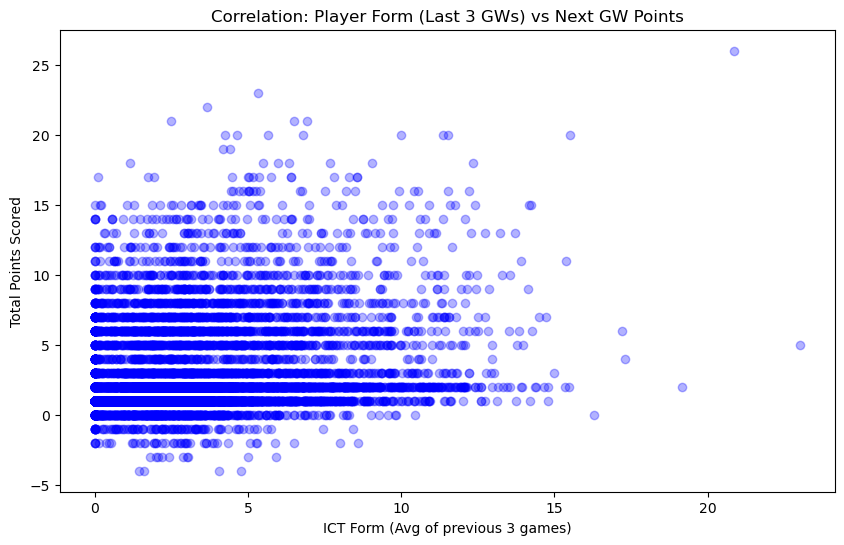

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df_viz['ict_form'], df_viz['total_points'], alpha=0.3, color='blue')
plt.title('Correlation: Player Form (Last 3 GWs) vs Next GW Points')
plt.xlabel('ICT Form (Avg of previous 3 games)')
plt.ylabel('Total Points Scored')
plt.savefig('evidence_scatter_plot.png') # This saves the image for your report
plt.show()

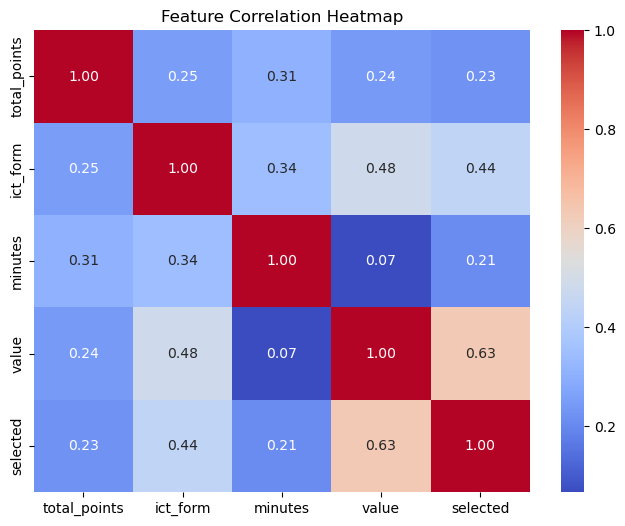

Success! Images saved as 'evidence_scatter_plot.png' and 'evidence_heatmap.png'.


In [10]:
plt.figure(figsize=(8, 6))
correlation_data = df_viz[['total_points', 'ict_form', 'minutes', 'value', 'selected']].corr()
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.savefig('evidence_heatmap.png') # This saves the image for your report
plt.show()

print("Success! Images saved as 'evidence_scatter_plot.png' and 'evidence_heatmap.png'.")